# Guitar string detection

Finds the 6 guitar strings on the fretboard in one image.

1. **Fretboard ROI**: the YOLO fretboard mask (`pipeline/fret_detect_yolo.py`) is warped to a 1024 x 256 rectangle, plus 30% padding above and below. The YOLO quad is often narrower than the strings, so without padding the outer strings get cut off.
2. **String detection** on that ROI, with two methods:
   - **A. Projection auto-tune (baseline)**: sum each row, then keep the 6 most prominent peaks. Strings come out as horizontal lines.
   - **B. `comb_band_slope_strip_fan` (proposed)**: enforces equal string spacing, uses the band crossed by frets, applies a common tilt, and refines each string strip by strip into slightly fanned lines.

Results on 31 held-out frames from the Roboflow "Guitars Strings & Frets" test split. A frame passes when the largest error is at most 0.25 of the string spacing:

| ROI + method | pass (≤ 0.25 spacing) |
| --- | --- |
| YOLO + A (projection auto-tune) | 10% |
| YOLO + 30% padding + A | 6% |
| YOLO + 30% padding + **B** | **55%** |

Parameters for B were tuned on the Roboflow valid split plus 14 hand-labeled frames. The test split was not used for tuning. B takes about 45 ms per frame, A about 1 ms.

**Running it:** start Jupyter from the repo root or from `notebooks/`, and fetch the YOLO checkpoint with `git lfs pull`. The repo contains no images, so set `IMAGE_PATH` to your own frame. The saved outputs come from `guitar-1829.jpg` in the test split of the Roboflow [Guitars Strings & Frets](https://universe.roboflow.com/test-l4egp/guitars-strings-frets-zupqa) dataset (v8, MIT). Section 4 runs only when `LABEL_PATH` exists: a JSON file with `{"strings": [{"p1": [x, y], "p2": [x, y]}, ...]}`, six strings in original-image pixels. `notebooks/data/` is git-ignored.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import signal

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from pipeline import fret_detect_yolo as fy

DATA_DIR = REPO_ROOT / "notebooks" / "data"
IMAGE_PATH = DATA_DIR / "guitar-1829.jpg"          # your frame (not in the repo)
LABEL_PATH = DATA_DIR / "guitar-1829_strings.json"  # optional ground-truth string lines
YOLO_WEIGHTS = REPO_ROOT / "pipeline" / "yolo_weights_best.pt"
N = 6  # strings

## 1. Fretboard ROI (YOLO + 30% padding)

`to_frame` maps lines from ROI coordinates back to the original frame through the inverse homography.

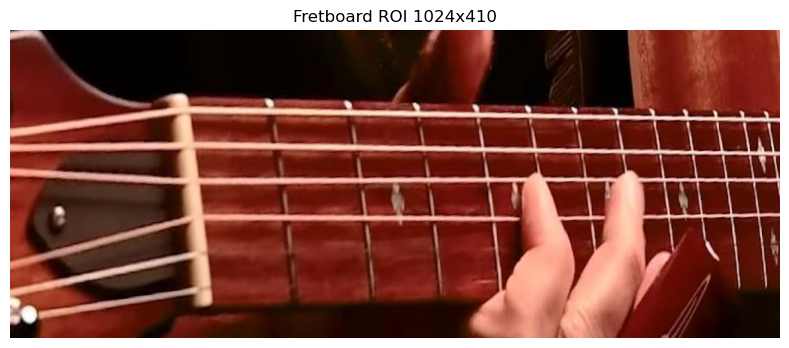

In [2]:
ROI_PAD = 0.3


def fretboard_roi(img_bgr, model, pad=ROI_PAD):
    # Returns (roi_bgr, to_frame, quad), or None when YOLO finds no fretboard.
    pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    rect = fy.rectify_perspective(pil, fy.predict_mask(model, pil), return_details=True)
    if rect is None:
        return None
    w, h = rect["image"].shape[1], rect["image"].shape[0]
    mh = int(round(pad * h))
    transform = np.array([[1, 0, 0], [0, 1, mh], [0, 0, 1]], float) @ rect["transform"]
    roi = cv2.warpPerspective(img_bgr, transform, (w, h + 2 * mh))
    inv = np.linalg.inv(transform)

    def to_frame(lines):
        lines = np.asarray(lines, float)
        pts = np.column_stack([lines.reshape(-1, 2), np.ones(2 * len(lines))]) @ inv.T
        return (pts[:, :2] / pts[:, 2:]).reshape(-1, 4)

    return roi, to_frame, rect["corners"].astype(np.float32)


model = fy.load_yolo_model(str(YOLO_WEIGHTS))
img = cv2.imread(str(IMAGE_PATH))
if img is None:
    raise FileNotFoundError(IMAGE_PATH)
found = fretboard_roi(img, model)
if found is None:
    raise RuntimeError("YOLO found no fretboard")
roi, to_frame, quad = found

plt.figure(figsize=(12, 4))
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title(f"Fretboard ROI {roi.shape[1]}x{roi.shape[0]}")
plt.axis("off")
plt.show()

## 2-A. Projection auto-tune (baseline)

CLAHE, then a 5x5 blur, then the row sum gives a horizontal projection. The 6 peaks with the highest prominence are kept. If only 5 are found, the missing string is filled in from the median spacing.

In [3]:
DETECT_Y_MIN = 5      # exclude row_index <= 5 (top-edge noise)
DETECT_Y_MARGIN = 8   # exclude row_index >= H - 8 (bottom-edge noise)


def _interpolate_missing_string(peaks_sorted, target_n, y_min, y_max):
    # Insert one string when target_n - 1 were found: midpoint of a gap
    # >= 1.4 x median spacing, otherwise extrapolate at the front/back edge.
    n = len(peaks_sorted)
    if n == 0 or target_n - n != 1:
        return list(peaks_sorted)
    spacings = np.diff(peaks_sorted).astype(float)
    med_sp = float(np.median(spacings))
    if med_sp <= 0:
        return list(peaks_sorted)

    max_gap_idx = int(np.argmax(spacings))
    if spacings[max_gap_idx] >= 1.4 * med_sp:
        new_y = int(round((peaks_sorted[max_gap_idx] + peaks_sorted[max_gap_idx + 1]) / 2.0))
        new_y = int(np.clip(new_y, y_min + 1, y_max - 1))
        return sorted(list(peaks_sorted) + [new_y])

    pre_y = int(round(peaks_sorted[0] - med_sp))
    if pre_y > y_min:
        return sorted(list(peaks_sorted) + [pre_y])
    post_y = int(round(peaks_sorted[-1] + med_sp))
    if post_y < y_max:
        return sorted(list(peaks_sorted) + [post_y])
    return list(peaks_sorted)


def detect_strings_auto(roi_bgr, target_n=N, y_min=DETECT_Y_MIN, y_margin=DETECT_Y_MARGIN):
    # Row indices of the top target_n projection peaks by prominence.
    h = roi_bgr.shape[0]
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    blurred = cv2.GaussianBlur(clahe.apply(gray), (5, 5), 0)
    proj = np.sum(blurred, axis=1).astype(float)

    y_max = h - y_margin
    masked = proj.copy()
    masked[:y_min + 1] = 0
    masked[y_max:] = 0

    # shrink the minimum peak distance until target_n peaks exist
    min_dist = max(1, h // 10)
    peaks, props = np.array([], dtype=int), {}
    while min_dist >= 1:
        peaks, props = signal.find_peaks(masked, distance=min_dist, prominence=0)
        if len(peaks) >= target_n:
            break
        min_dist -= 1
    if len(peaks) == 0:
        return []

    k = min(target_n, len(peaks))
    top_idx = np.argsort(props["prominences"])[-k:]
    top_peaks = sorted(peaks[top_idx].tolist())
    if len(top_peaks) == target_n - 1:
        top_peaks = _interpolate_missing_string(top_peaks, target_n, y_min, y_max)
    return top_peaks


def auto_tune(roi_bgr):
    # Horizontal lines (x1, y1, x2, y2) in ROI coordinates.
    w = roi_bgr.shape[1]
    return [(0.0, float(y), float(w - 1), float(y)) for y in detect_strings_auto(roi_bgr)]

## 2-B. `comb_band_slope_strip_fan` (proposed)

| Step | What it does |
| --- | --- |
| ridge | Uses a thin-line response (negative 2nd derivative in y) instead of raw brightness, so strings give peaks and fretboard edges, which are brightness steps, give about 0 |
| slope | All strings share one tilt `m`: pick the shear that makes the row projection sharpest |
| comb | Model the 6 strings as `y0 + k*s` with equal spacing, and pick the `(y0, s)` that maximises the summed profile |
| band | Rows crossed by frets (long vertical edges) form the fretboard band. The comb center must sit near the band center and the spacing is tied to the band height, which stops the comb from shifting by a whole string |
| strip | Split the ROI into 8 vertical strips, search for each string near its comb position, drop weak peaks, and fit a robust line per string |
| fan | Force each string's slope to vary linearly with string rank, which models perspective fan-out |

In [4]:
SLOPES = np.linspace(-0.12, 0.12, 49)      # shear search range (dy/dx)
SPACING_RANGE = (0.08, 0.22)               # comb spacing as a fraction of ROI height
N_STRIPS = 8
SEARCH = 0.25                              # strip search window, +/- spacings
MIN_PROM = 0.6                             # drop strip peaks below this x median prominence
MAX_COLS = 512                             # columns used for projections
BAND_FRAC = 0.5                            # fret-energy threshold (fraction of range)
BAND_SPACINGS = (4.5, 7.0)                 # band height / string spacing
BAND_CENTER_TOL = 0.5                      # comb center vs band center, in spacings
RIDGE_SIGMA = 0.01                         # ridge scale as a fraction of ROI height


# ── image -> profile ──────────────────────────────────────────────────────
def _gray(roi_bgr):
    return cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)


def _ridge(roi_bgr):
    # Negative 2nd y-derivative of a Gaussian-smoothed image (thin bright
    # horizontal lines -> positive peak, brightness steps -> ~0).
    sig = max(0.7, RIDGE_SIGMA * roi_bgr.shape[0])
    g = cv2.GaussianBlur(_gray(roi_bgr), (0, 0), sigmaX=2.0, sigmaY=sig)
    return -cv2.Sobel(g, cv2.CV_32F, 0, 2, ksize=3) * sig ** 2


def _shear(img, m):
    # out[y, x] = img[y + m*(x - xc), x]: a line y = y0 + m*(x - xc) becomes row y0.
    h, w = img.shape[:2]
    if m == 0:
        return img
    xs = np.arange(w, dtype=np.float32)
    map_x = np.tile(xs, (h, 1))
    map_y = (np.arange(h, dtype=np.float32)[:, None] + m * (xs - (w - 1) / 2)).astype(np.float32)
    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)


def _cols(w):
    return np.linspace(0, w - 1, min(w, MAX_COLS)).astype(int)


def _profile(img, cols=None):
    # median over columns: robust to fingers covering part of a string
    return np.median(img[:, cols] if cols is not None else img, axis=1)


def best_slope(img):
    # The shear whose row projection has the most gradient energy.
    cols = _cols(img.shape[1])
    sub = img[:, cols]
    h = sub.shape[0]
    xs = cols.astype(np.float32)
    map_x = np.tile(np.arange(len(cols), dtype=np.float32), (h, 1))
    scores = []
    for m in SLOPES:
        # shear the column subset; x offsets must use the full-width coordinates
        map_y = (np.arange(h, dtype=np.float32)[:, None] + m * (xs - (img.shape[1] - 1) / 2)).astype(np.float32)
        p = cv2.remap(sub, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE).mean(axis=1)
        scores.append(float(np.sum(np.diff(p) ** 2)))
    return float(SLOPES[int(np.argmax(scores))])


def fret_band(roi_bgr):
    # (top, bottom) rows of the fretboard: contiguous band of high fret
    # (vertical-edge) energy around its maximum. None if degenerate.
    h = roi_bgr.shape[0]
    g = cv2.GaussianBlur(_gray(roi_bgr), (0, 0), 1.0)
    gx = np.abs(cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3))
    gx = cv2.blur(gx, (1, max(3, int(h * 0.05))))      # keep vertically consistent edges
    e = cv2.GaussianBlur(gx.mean(axis=1).reshape(-1, 1), (0, 0), max(1.0, 0.03 * h)).ravel()
    thr = e.min() + BAND_FRAC * (e.max() - e.min())
    t = b = int(np.argmax(e))
    while t > 0 and e[t - 1] >= thr:
        t -= 1
    while b < h - 1 and e[b + 1] >= thr:
        b += 1
    return (t, b) if b - t >= 0.2 * h else None


# ── comb: equal spacing ───────────────────────────────────────────────────
def comb_fit(p, h, band=None):
    # Best (y0, s) for 6 equally spaced teeth; band = (top, bottom) restricts
    # the spacing and the comb center.
    p = np.asarray(p, dtype=float)
    p = p - np.median(p)
    lo, hi = SPACING_RANGE[0] * h, SPACING_RANGE[1] * h
    if band is not None:
        bh = band[1] - band[0]
        lo, hi = max(lo, bh / BAND_SPACINGS[1]), min(hi, bh / BAND_SPACINGS[0])
        if lo > hi:
            lo, hi = bh / BAND_SPACINGS[1], bh / BAND_SPACINGS[0]
    best = (-np.inf, None, None)
    k = np.arange(N)
    y = np.arange(len(p), dtype=float)
    for s in np.arange(lo, hi + 1e-9, 0.5):
        y0s = np.arange(0, len(p) - 1 - (N - 1) * s, 0.5)
        if band is not None:
            c = (band[0] + band[1]) / 2 - (N - 1) / 2 * s
            y0s = y0s[np.abs(y0s - c) <= BAND_CENTER_TOL * s]
        if len(y0s) == 0:
            continue
        teeth = y0s[:, None] + k[None, :] * s
        score = np.interp(teeth, y, p).sum(axis=1)
        j = int(np.argmax(score))
        if score[j] > best[0]:
            best = (score[j], y0s[j], s)
    _, y0, s = best
    if y0 is None:
        return None, None
    return y0 + k * s, s


# ── strips + fan ──────────────────────────────────────────────────────────
def _subpixel(p, i):
    if 0 < i < len(p) - 1:
        a, b, c = p[i - 1], p[i], p[i + 1]
        den = a - 2 * b + c
        if den < 0:
            return i + 0.5 * (a - c) / den
    return float(i)


def strip_refine(img, lines_y, m, s):
    # lines_y: y of each string at the ROI center (after shear by m).
    # Returns 6 lines (x1, y1, x2, y2) in ROI coords.
    h, w = img.shape
    xc = (w - 1) / 2
    sheared = _shear(img, m)
    edges = np.linspace(0, w, N_STRIPS + 1).astype(int)
    det = []  # (string, x_center, y_frame, prominence)
    for a, b in zip(edges[:-1], edges[1:]):
        p = np.median(sheared[:, a:b], axis=1)
        x_mid = (a + b - 1) / 2
        for i, y in enumerate(lines_y):
            lo, hi = int(max(0, np.floor(y - SEARCH * s))), int(min(h - 1, np.ceil(y + SEARCH * s)))
            if hi - lo < 2:
                continue
            win = p[lo:hi + 1]
            j = int(np.argmax(win))
            if j in (0, len(win) - 1):          # no interior peak in the window
                continue
            prom = win[j] - win.min()
            ys = _subpixel(p, lo + j)
            det.append((i, x_mid, ys + m * (x_mid - xc), prom))
    det = np.array(det) if det else np.zeros((0, 4))
    if len(det):
        det = det[det[:, 3] >= MIN_PROM * np.median(det[:, 3])]

    # robust line per string: y = a + b*x
    fits = []
    for i, y in enumerate(lines_y):
        d = det[det[:, 0] == i] if len(det) else det
        a_, b_ = y - m * xc, m                    # fallback: global line
        n_pts = len(d)
        if n_pts >= 3:
            x, yy = d[:, 1], d[:, 2]
            keep = np.ones(n_pts, bool)
            for _ in range(3):
                b_, a_ = np.polyfit(x[keep], yy[keep], 1)
                r = np.abs(yy - (a_ + b_ * x))
                new = r <= max(0.15 * s, 1.0)
                if new.sum() < 3 or np.array_equal(new, keep):
                    break
                keep = new
            n_pts = int(keep.sum())
        fits.append((a_, b_, n_pts, d))

    # fan: slopes linear in string rank
    slopes = np.array([f[1] for f in fits])
    wts = np.array([max(f[2], 0.5) for f in fits])
    c1, c0 = np.polyfit(np.arange(N), slopes, 1, w=np.sqrt(wts))
    lines = []
    for i, (a_, b_, n_pts, d) in enumerate(fits):
        b2 = c0 + c1 * i
        a2 = float(np.median(d[:, 2] - b2 * d[:, 1])) if n_pts >= 1 else a_ + (b_ - b2) * xc
        lines.append((0.0, a2, float(w - 1), a2 + b2 * (w - 1)))
    return lines


def comb_band_slope_strip_fan(roi_bgr):
    # Lines (x1, y1, x2, y2) in ROI coordinates, [] on failure.
    r = _ridge(roi_bgr)
    m = best_slope(r)
    ys, s = comb_fit(_profile(_shear(r, m), _cols(r.shape[1])), r.shape[0], fret_band(roi_bgr))
    if ys is None:
        return []
    return strip_refine(r, ys, m, s)

## 3. Run both methods

Top: both methods on the same ROI. Bottom: the proposed method's lines mapped back to the original frame, with the ground truth as white lines.

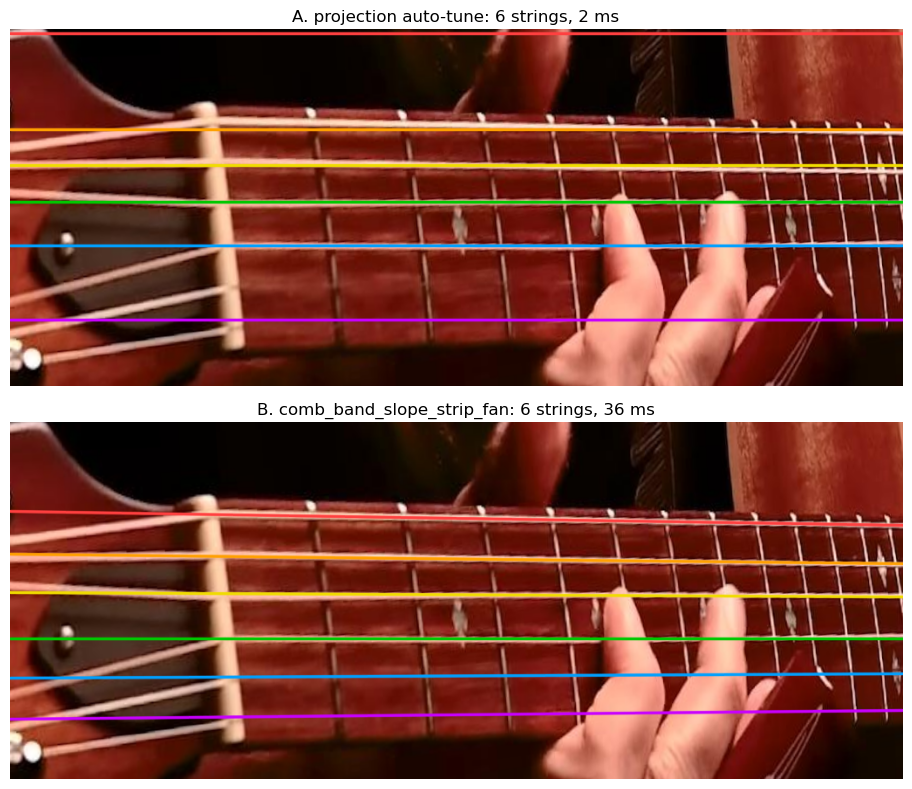

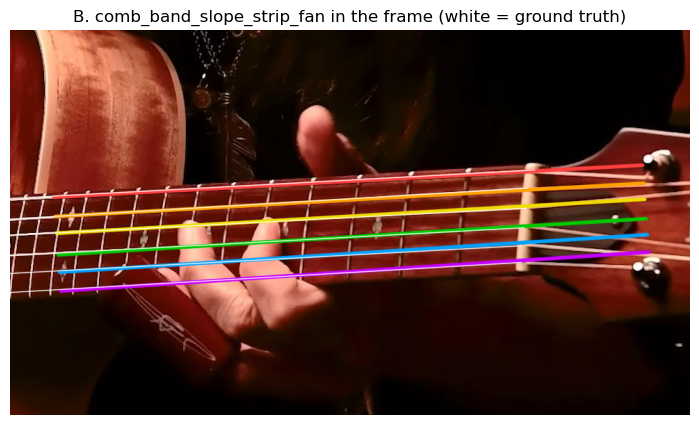

In [5]:
import json
import time

METHODS = {"A. projection auto-tune": auto_tune, "B. comb_band_slope_strip_fan": comb_band_slope_strip_fan}
COLORS = [(255, 64, 64), (255, 160, 0), (240, 220, 0), (0, 200, 0), (0, 160, 255), (200, 0, 255)]


def draw_lines(img_bgr, lines, thickness=2):
    out = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    for (x1, y1, x2, y2), c in zip(lines, COLORS):
        cv2.line(out, (int(round(x1)), int(round(y1))), (int(round(x2)), int(round(y2))), c, thickness, cv2.LINE_AA)
    return out


results = {}
fig, axes = plt.subplots(len(METHODS), 1, figsize=(12, 4 * len(METHODS)))
for ax, (name, fn) in zip(axes, METHODS.items()):
    t0 = time.perf_counter()
    lines = fn(roi)
    ms = (time.perf_counter() - t0) * 1000
    results[name] = lines
    ax.imshow(draw_lines(roi, lines))
    ax.set_title(f"{name}: {len(lines)} strings, {ms:.0f} ms")
    ax.axis("off")
plt.tight_layout()
plt.show()

gt = None
if LABEL_PATH.exists():
    label = json.load(open(LABEL_PATH))
    gt = np.array([s["p1"] + s["p2"] for s in label["strings"]], float)

frame_lines = to_frame(results["B. comb_band_slope_strip_fan"])
vis = draw_lines(img, frame_lines, thickness=3)
for x1, y1, x2, y2 in (gt if gt is not None else []):
    cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 255, 255), 1, cv2.LINE_AA)
qx, qy = quad[:, 0], quad[:, 1]
pad = 60
x0, x1_ = int(max(qx.min() - pad, 0)), int(min(qx.max() + pad, img.shape[1]))
y0, y1_ = int(max(qy.min() - 3 * pad, 0)), int(min(qy.max() + 3 * pad, img.shape[0]))
plt.figure(figsize=(14, 5))
plt.imshow(vis[y0:y1_, x0:x1_])
plt.title("B. comb_band_slope_strip_fan in the frame" + (" (white = ground truth)" if gt is not None else ""))
plt.axis("off")
plt.show()

## 4. Error against the ground truth

This is the same metric as the evaluation table at the top. Both the predicted and the ground-truth lines are sorted top to bottom. At 21 x positions, where the labeled strings overlap the YOLO quad, the vertical error is divided by the local string spacing. A frame passes when the largest error is at most 0.25 spacing.

In [6]:
def y_at(lines, x):
    # y of each line at positions x -> (n_lines, len(x))
    x1, y1, x2, y2 = np.asarray(lines, float).T
    return y1[:, None] + ((y2 - y1) / (x2 - x1))[:, None] * (x[None, :] - x1[:, None])


def score_lines(gt, pred, xs):
    yg = np.sort(y_at(gt, xs), axis=0)
    spacing = np.median(np.diff(yg, axis=0), axis=0)
    if len(pred) != len(gt):
        return None
    err = (np.sort(y_at(pred, xs), axis=0) - yg) / spacing
    return float(np.abs(err).max()), float(np.abs(err).mean()), float(np.median(spacing))


if gt is None:
    print(f"No ground truth at {LABEL_PATH}, skipping.")
else:
    qx_sorted = np.sort(quad[:, 0])
    xs = np.linspace(max(qx_sorted[1], gt[:, [0, 2]].min()), min(qx_sorted[2], gt[:, [0, 2]].max()), 21)
    print(f"{'method':32s} {'max err':>8s} {'mean err':>9s}  (in string spacings)")
    for name, lines in results.items():
        sc = score_lines(gt, to_frame(lines), xs)
        if sc is None:
            print(f"{name:32s} wrong string count ({len(lines)})")
            continue
        mx, mean, sp = sc
        print(f"{name:32s} {mx:8.2f} {mean:9.2f}  {'PASS' if mx <= 0.25 else 'FAIL'}")
    print(f"\nstring spacing ~ {sp:.1f} px")

method                            max err  mean err  (in string spacings)
A. projection auto-tune              2.63      1.09  FAIL
B. comb_band_slope_strip_fan         0.20      0.06  PASS

string spacing ~ 26.3 px


## Limitations

- When YOLO misses the fretboard (about 18% of Roboflow images), there is no ROI and nothing is detected.
- The fret band fails on fretboards with large inlays, and the comb can then shift by one string.
- String order is screen order (top to bottom). Which line is high E and which is low E is not decided here.